Internal absorption
====================

In [1]:
import jetset
print('tested with',jetset.__version__)

tested with 1.4.0rc3


In this tutorial we show how to use the internal absorption for external radiative fields.

We first create a leptonic jet model with e EC components.

In [2]:
from jetset.jet_model import Jet
import numpy as np
from jetset.template_2Dmodel import EBLAbsorptionTemplate
import astropy.units as u

ebl_dominguez_2010=EBLAbsorptionTemplate.from_name('Dominguez_2010_v2011')
ebl_dominguez_lopez=EBLAbsorptionTemplate.from_name('Dominguez_2023')
ebl_finke=EBLAbsorptionTemplate.from_name('Finke_2010')
ebl_franceschini=EBLAbsorptionTemplate.from_name('Franceschini_2008')


jetset_model = Jet(name="compact_int_abs",emitters_distribution="bkn",beaming_expr='bulk_theta')
jetset_model.add_EC_component(EC_components_list=['EC_DT','EC_BLR','EC_Corona'],disk_type='BB')
jetset_model.make_conical_jet(theta_open=5,R=1E16)
jetset_model.set_EC_dependencies()

jetset_model.set_par('L_Disk',val=2E45)
jetset_model.set_par('gmax',val=5E5)
jetset_model.set_par('gmin',val=2.)
jetset_model.set_par('R_H',val=1E17)

jetset_model.set_par('p',val=1.5)
jetset_model.set_par('p_1',val=3.2)
jetset_model.set_par('B',val=1.5)
jetset_model.set_par('z_cosm',val=0.6)
jetset_model.set_par('BulkFactor',val=10)
jetset_model.set_par('theta',val=1)
jetset_model.set_par('gamma_break',val=5E2)
jetset_model.parameters.tau_DT.val=0.1
jetset_model.parameters.T_DT.val=1000
jetset_model.parameters.theta.freeze()
jetset_model.parameters.R_H.val=1E18
jetset_model.set_N_from_nuFnu(nu_obs=1E13,nuFnu_obs=1E-13)
jetset_model.set_external_field_transf('blob')



adding par: R_H to  R
adding par: theta_open to  R
==> par R is depending on ['R_H', 'theta_open'] according to expr:   R =
np.tan(np.radians(theta_open))*R_H
setting R_H to 1.1430052302761344e+17
adding par: L_Disk to  R_BLR_in
==> par R_BLR_in is depending on ['L_Disk'] according to expr:   R_BLR_in =
3E17*(L_Disk/1E46)**0.5
adding par: R_BLR_in to  R_BLR_out
==> par R_BLR_out is depending on ['R_BLR_in'] according to expr:   R_BLR_out =
R_BLR_in*1.1
adding par: L_Disk to  R_DT
==> par R_DT is depending on ['L_Disk'] according to expr:   R_DT =
2E19*(L_Disk/1E46)**0.5


In [3]:
jetset_model


--------------------------------------------------------------------------------
model description: 
--------------------------------------------------------------------------------
type: Jet
name: compact_int_abs  
geometry: spherical  

electrons distribution:
 type: bkn  
 gamma energy grid size:  201
 gmin grid : 2.000000e+00
 gmax grid : 5.000000e+05
 normalization:  True
 log-values:  False
 ratio of cold protons to relativistic electrons: 1.000000e+00

accretion disk:
 disk Type: BB
 L disk: 2.000000e+45 (erg/s)
 T disk: 1.000000e+05 (K)
 nu peak disk: 8.171810e+15 (Hz)
radiative fields:
 seed photons grid size:  100
 IC emission grid size:  100
 source emissivity lower bound :  1.000000e-120
 spectral components:
   name:Sum, state: on
   name:Sum, hidden: False
   name:Sync, state: self-abs
   name:Sync, hidden: False
   name:SSC, state: on
   name:SSC, hidden: False
   name:EC_DT, state: on
   name:EC_DT, hidden: False
   name:DT, state: on
   name:DT, hidden: False
   name:

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
compact_int_abs,"*R(D,theta_open)",region_size,cm,8.748866e+16,1.000000e+03,1.000000e+30,False,True
compact_int_abs,R_H(M),region_position,cm,1.000000e+18,0.000000e+00,--,False,False
compact_int_abs,B,magnetic_field,gauss,1.500000e+00,0.000000e+00,--,False,False
compact_int_abs,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
compact_int_abs,theta,jet-viewing-angle,deg,1.000000e+00,0.000000e+00,9.000000e+01,False,True
compact_int_abs,BulkFactor,jet-bulk-factor,lorentz-factor*,1.000000e+01,1.000000e+00,1.000000e+05,False,False
compact_int_abs,z_cosm,redshift,,6.000000e-01,0.000000e+00,--,False,False
compact_int_abs,gmin,low-energy-cut-off,lorentz-factor*,2.000000e+00,1.000000e+00,1.000000e+09,False,False
compact_int_abs,gmax,high-energy-cut-off,lorentz-factor*,5.000000e+05,1.000000e+00,1.000000e+15,False,False
compact_int_abs,N,emitters_density,1 / cm3,6.143592e-02,0.000000e+00,--,False,False


--------------------------------------------------------------------------------


None

Now we can enable the internal absorption for the BLR and DT fields, and evaluate the model with internal absorption applied

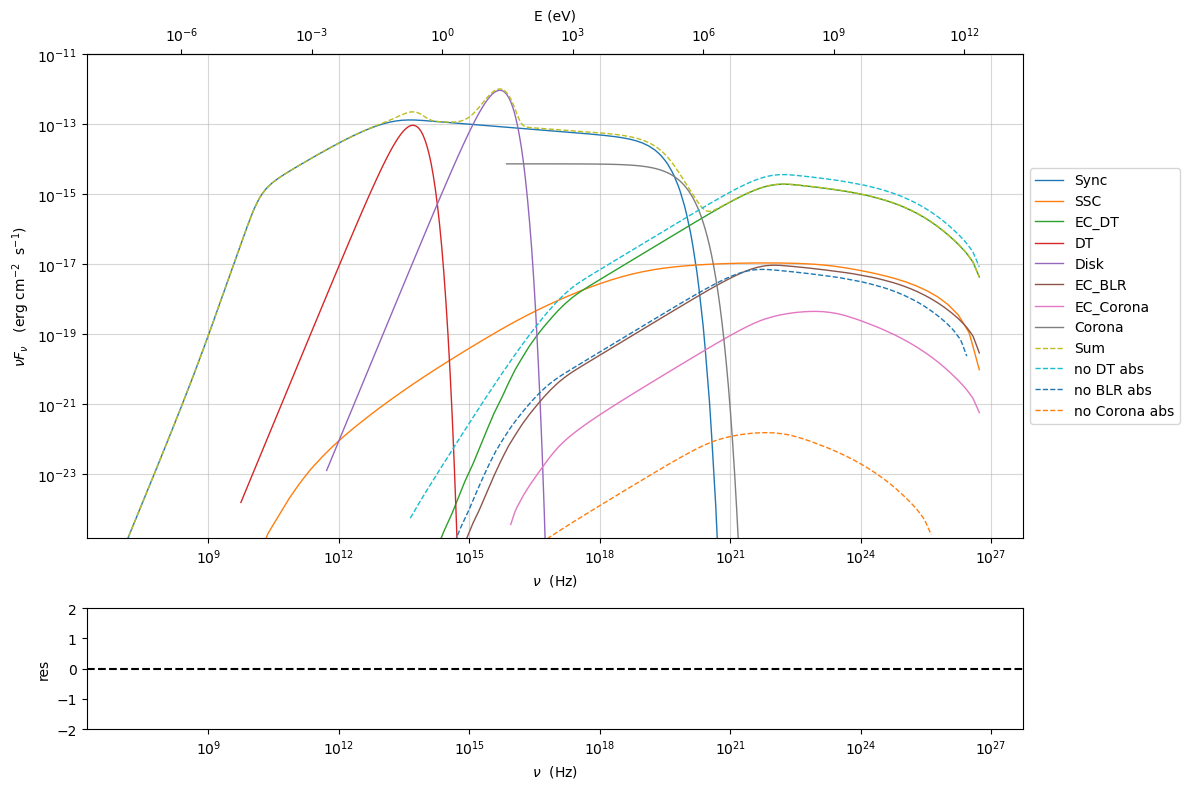

In [4]:
jetset_model.remove_internal_absorption('DT',)
jetset_model.remove_internal_absorption('BLR', )
jetset_model.remove_internal_absorption('Corona')

jetset_model.eval()
p=jetset_model.plot_model()

#jetset_model.remove_internal_absorption('DT')
#jetset_model.remove_internal_absorption('BLR')
#jetset_model.remove_internal_absorption('Corona')
jetset_model.set_external_field_transf('disk')

jetset_model.eval()
jetset_model.plot_model(plot_obj=p,comp='EC_DT',label='no DT abs',line_style='--')
jetset_model.plot_model(plot_obj=p,comp='EC_BLR',label='no BLR abs',line_style='--')
jetset_model.plot_model(plot_obj=p,comp='EC_Corona',label='no Corona abs',line_style='--')


In [5]:

jetset_model.enable_internal_absorption('DT')
jetset_model.enable_internal_absorption('BLR')
jetset_model.enable_internal_absorption('Corona')


This model can be used now for model fitting.

In [6]:
jetset_model.show_internal_absorption_components()

internal absorption  for component: DT
('N_hard', 20)
('N_soft', 50)
('N_theta', 30)
('N_R_H', 20)
('nu_min', None)
('comp', 'DT')
('use_R_H_profile_extrapolation', False)
('use_sigma_gamma_gamma_fast', False)

internal absorption  for component: BLR
('N_hard', 20)
('N_soft', 50)
('N_theta', 30)
('N_R_H', 20)
('nu_min', None)
('comp', 'BLR')
('use_R_H_profile_extrapolation', False)
('use_sigma_gamma_gamma_fast', False)

internal absorption  for component: Corona
('N_hard', 20)
('N_soft', 50)
('N_theta', 30)
('N_R_H', 20)
('nu_min', None)
('comp', 'Corona')
('use_R_H_profile_extrapolation', False)
('use_sigma_gamma_gamma_fast', False)



Please, notice that the internal absorption will slow down a bit the computation. Let's quantify the effect for a single component. 
First we remove the BLR and Corona absorption, to assess the impact of a single component.

In [7]:
jetset_model.remove_internal_absorption('BLR')
jetset_model.remove_internal_absorption('Corona')

jetset_model.show_internal_absorption_components()

internal absorption  for component: DT
('N_hard', 20)
('N_soft', 50)
('N_theta', 30)
('N_R_H', 20)
('nu_min', None)
('comp', 'DT')
('use_R_H_profile_extrapolation', False)
('use_sigma_gamma_gamma_fast', False)



In [8]:
%timeit jetset_model.eval()

8.26 ms ± 130 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [9]:
jetset_model.remove_internal_absorption('DT')


In [10]:
%timeit jetset_model.eval()
jetset_model.show_internal_absorption_components()

8.15 ms ± 25.3 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
internal absorption not enabled in this jet model


The increase in computational time, for component, compared to an EC model without absorption, is of a factor of ~ 2.5 


By setting `use_R_H_profile_extrapolation=True`, we can speed up the process

In [11]:
jetset_model.enable_internal_absorption('DT',use_R_H_profile_extrapolation=False)


In [12]:
%timeit _=jetset_model.eval_internal_absorption(comp='DT', peak=False)

1.08 ms ± 2.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [13]:
jetset_model.enable_internal_absorption('DT',use_R_H_profile_extrapolation=True)


In [14]:
%timeit _=jetset_model.eval_internal_absorption(comp='DT', peak=False)

981 μs ± 2.75 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


By setting `use_sigma_gamma_gamma_fast=True`, we can further speed up the process, by using interpolated cross section.

In [15]:
jetset_model.enable_internal_absorption('DT',use_sigma_gamma_gamma_fast=True,use_R_H_profile_extrapolation=True)


In [16]:
%timeit _=jetset_model.eval_internal_absorption(comp='DT', peak=False)

587 μs ± 945 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [17]:
jetset_model.enable_internal_absorption('DT',use_R_H_profile_extrapolation=True,use_sigma_gamma_gamma_fast=True)

%timeit jetset_model.eval()

8.17 ms ± 19.7 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [18]:
jetset_model.enable_internal_absorption('DT',use_R_H_profile_extrapolation=True)
jetset_model.enable_internal_absorption('BLR',use_R_H_profile_extrapolation=True)
jetset_model.enable_internal_absorption('Corona',use_R_H_profile_extrapolation=True)


%timeit jetset_model.eval()

8.21 ms ± 11.4 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


The increase in computational time is lower now, down to a factor of ~1.1 per absorption component. 



In the following some plots showing the accuracy effect when using `use_R_H_profile_extrapolation=True`, so you can choose accordingly, if whether to use the approximation or not.

In [19]:
jetset_model.remove_internal_absorption('BLR')
jetset_model.remove_internal_absorption('DT')

jetset_model.enable_internal_absorption('DT',use_R_H_profile_extrapolation=True,use_sigma_gamma_gamma_fast=True)
jetset_model.enable_internal_absorption('BLR',use_R_H_profile_extrapolation=True,use_sigma_gamma_gamma_fast=True)

%timeit jetset_model.eval()

8.48 ms ± 309 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


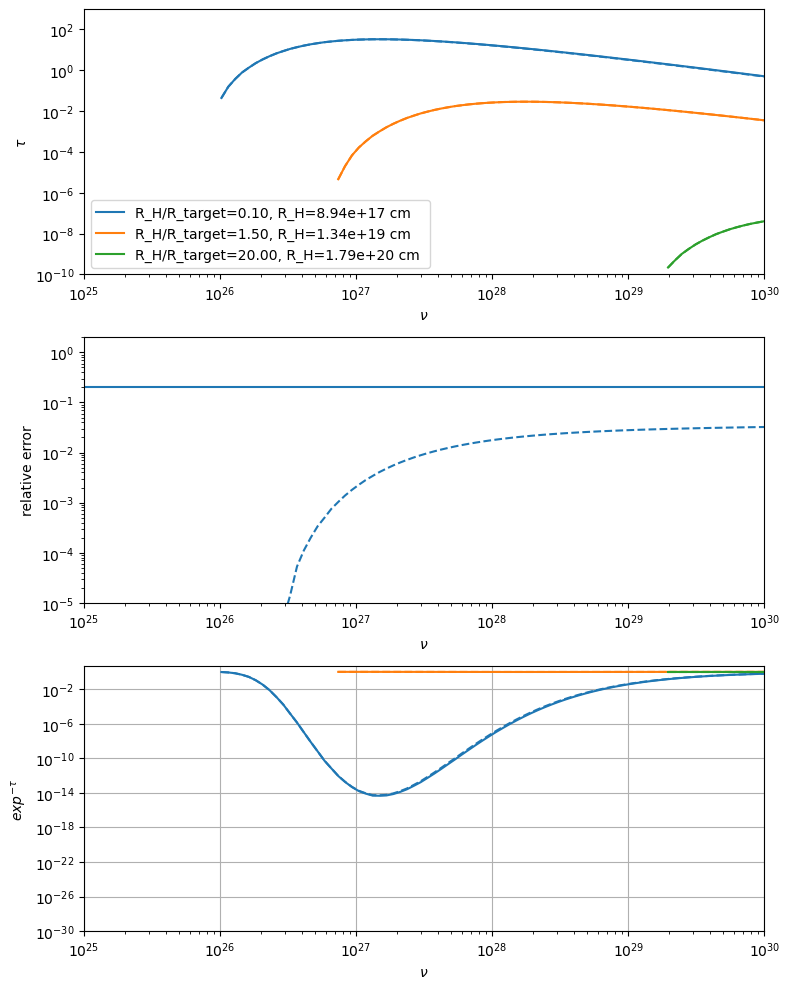

In [20]:
from matplotlib import pylab as plt
jetset_model.parameters.tau_BLR.val=0.1
#jetset_model.parameters.T_DT.val=1000
fig,axs=plt.subplots(3,1,figsize=(8,10))
R_DT=jetset_model.parameters.R_DT.val
colors = ['C0','C1','C2']
comp='DT'
jetset_model.enable_internal_absorption(comp,N_R_H=50,N_theta=50,N_soft=50,N_hard=50,use_R_H_profile_extrapolation=False)
nu_hard_min=1E25
nu_tau=np.logspace(np.log10(nu_hard_min),30,100)

for ID,f in enumerate([.1,1.5,20]):
    jetset_model.parameters.R_H.val=R_DT*f
    jetset_model.eval()
    
    y,x=jetset_model.eval_internal_absorption(comp=comp,peak=False,nu=nu_tau)
    
    x=x*u.Hz
    msk=y>1E-10

    axs[0].loglog( x[msk],y[msk],c=colors[ID],label='R_H/R_target=%2.2f, R_H=%2.2e cm '%(f,jetset_model.parameters.R_H.val))

    jetset_model.enable_internal_absorption(comp,N_R_H=50,N_theta=50,N_soft=50,N_hard=50,use_R_H_profile_extrapolation=True,use_sigma_gamma_gamma_fast=False)
    y1,x=jetset_model.eval_internal_absorption(comp=comp,peak=False,nu=nu_tau)
    x=x*u.Hz
    axs[0].loglog( x[msk] ,y1[msk] ,'--',c=colors[ID])

    axs[1].loglog( x[msk],np.fabs(y1[msk] -y [msk])/y[msk],'--',c=colors[ID])

    axs[2].loglog( x[msk],np.exp(-y[msk]),'-',c=colors[ID])
    axs[2].loglog( x[msk],np.exp(-y1[msk]),'--',c=colors[ID])
    x_min=min(nu_hard_min,x[msk].value.min()/2)
axs[0].set_xlim(x_min,1E30)
axs[1].set_xlim(x_min,1E30)
axs[2].set_xlim(x_min,1E30)
axs[0].legend()


axs[1].axhline(.2)

axs[0].set_ylim(1E-10,1E3)
axs[1].set_ylim(1E-5,2)
axs[2].set_ylim(1E-30,)
axs[0].set_xlabel(r'$\nu$')
axs[1].set_xlabel(r'$\nu$')
axs[2].set_xlabel(r'$\nu$')

axs[0].set_ylabel(r'$\tau$')
axs[1].set_ylabel(r'relative error')
axs[2].set_ylabel(r'$exp^{-\tau}$')
plt.tight_layout()
plt.grid()

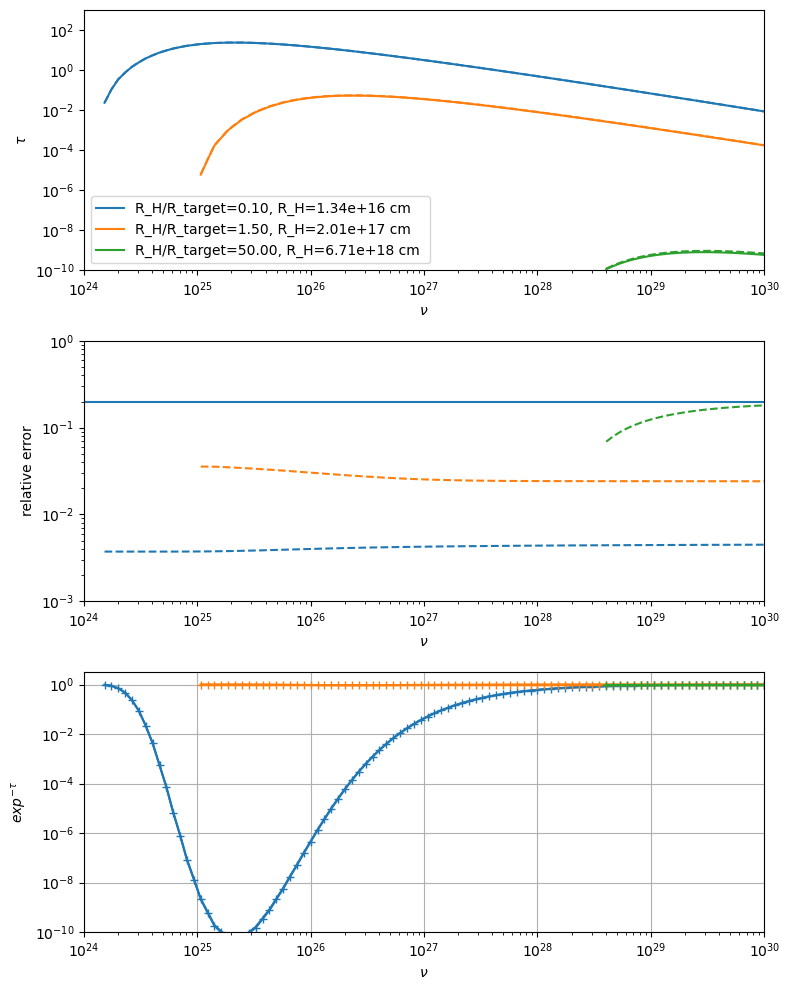

In [21]:
from matplotlib import pylab as plt
jetset_model.parameters.tau_BLR.val=0.1
#jetset_model.parameters.T_DT.val=1000
fig,axs=plt.subplots(3,1,figsize=(8,10))
R_BLR=jetset_model.parameters.R_BLR_in.val
colors = ['C0','C1','C2']
comp='BLR'
jetset_model.enable_internal_absorption(comp,N_R_H=50,N_theta=50,N_soft=50,N_hard=50,use_R_H_profile_extrapolation=False)
nu_hard_min=1E24
nu_tau=np.logspace(np.log10(nu_hard_min),30,100)
for ID,f in enumerate([.1,1.5,50]):
    jetset_model.parameters.R_H.val=R_BLR*f
    jetset_model.eval()
    jetset_model.enable_internal_absorption(comp,N_R_H=50,N_theta=50,N_soft=50,N_hard=50,use_R_H_profile_extrapolation=False)
    y,x=jetset_model.eval_internal_absorption(comp=comp,peak=False,nu=nu_tau)

    x=x*u.Hz
    msk=y>1E-10

    axs[0].loglog( x[msk],y[msk],c=colors[ID],label='R_H/R_target=%2.2f, R_H=%2.2e cm '%(f,jetset_model.parameters.R_H.val))

    jetset_model.enable_internal_absorption(comp,N_R_H=50,N_theta=50,N_soft=50,N_hard=50,use_R_H_profile_extrapolation=True,use_sigma_gamma_gamma_fast=False)
    y1,x=jetset_model.eval_internal_absorption(comp=comp,peak=False,nu=nu_tau)
    x=x*u.Hz
    axs[0].loglog( x[msk] ,y1[msk] ,'--',c=colors[ID])
    axs[1].loglog( x[msk],np.fabs(y1[msk] -y [msk])/y[msk],'--',c=colors[ID])

    axs[2].loglog( x[msk],np.exp(-y[msk]),'-',c=colors[ID])
    axs[2].loglog( x[msk],np.exp(-y1[msk]),'-+',c=colors[ID])
    x_min=min(nu_hard_min,x[msk].value.min()/2)
axs[0].set_xlim(x_min,1E30)
axs[1].set_xlim(x_min,1E30)
axs[2].set_xlim(x_min,1E30)
axs[0].legend()

axs[1].axhline(.2)

axs[0].set_ylim(1E-10,1E3)
axs[1].set_ylim(1E-3,1)
axs[2].set_ylim(1E-10,)
axs[0].set_xlabel(r'$\nu$')
axs[1].set_xlabel(r'$\nu$')
axs[2].set_xlabel(r'$\nu$')

axs[0].set_ylabel(r'$\tau$')
axs[1].set_ylabel(r'relative error')
axs[2].set_ylabel(r'$exp^{-\tau}$')
plt.tight_layout()
plt.grid()

3.593865310093714e-10
0.0
0.0


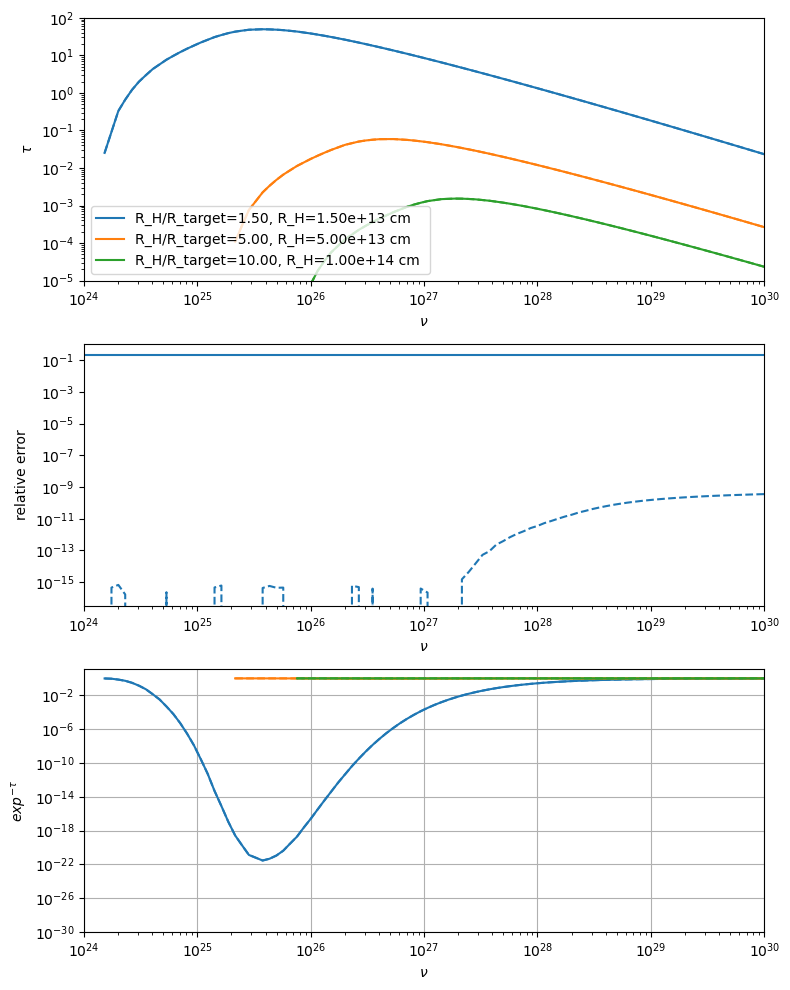

In [22]:
from matplotlib import pylab as plt
#jetset_model.parameters.T_DT.val=1000
fig,axs=plt.subplots(3,1,figsize=(8,10))
jetset_model.parameters.R_H_Corona.val=1E13
colors = ['C0','C1','C2']
comp='Corona'
nu_hard_min=1E24
nu_tau=np.logspace(np.log10(nu_hard_min),30,100)
jetset_model.enable_internal_absorption(comp,N_R_H=50,N_theta=50,N_soft=50,N_hard=50,use_R_H_profile_extrapolation=False)

R_H_corona=jetset_model.parameters.R_H_Corona.val
for ID,f in enumerate([1.5,5,10]):
    jetset_model.parameters.R_H.val=R_H_corona*f
    jetset_model.eval()
    
    y,x=jetset_model.eval_internal_absorption(comp=comp,peak=False,nu=nu_tau)
    x=x*u.Hz
    msk=y>1E-10

    axs[0].loglog( x[msk],y[msk],c=colors[ID],label='R_H/R_target=%2.2f, R_H=%2.2e cm '%(f,jetset_model.parameters.R_H.val))

    jetset_model.enable_internal_absorption(comp,N_R_H=50,N_theta=50,N_soft=50,N_hard=50,use_R_H_profile_extrapolation=True,use_sigma_gamma_gamma_fast=False)
    y1,x=jetset_model.eval_internal_absorption(comp=comp,peak=False,nu=nu_tau)
    x=x*u.Hz
    axs[0].loglog( x[msk] ,y1[msk] ,'--',c=colors[ID])

    axs[1].loglog( x[msk],np.fabs(y1[msk] -y [msk])/y[msk],'--',c=colors[ID])

    axs[2].loglog( x[msk],np.exp(-y[msk]),'-',c=colors[ID])
    axs[2].loglog( x[msk],np.exp(-y1[msk]),'--',c=colors[ID])
    x_min=min(nu_hard_min,x[msk].value.min()/2)
    print(np.max(np.fabs(y1[msk] -y [msk])/y[msk]))
axs[0].set_xlim(x_min,1E30)
axs[1].set_xlim(x_min,1E30)
axs[2].set_xlim(x_min,1E30)
axs[0].legend()



axs[1].axhline(.2)

axs[0].set_ylim(1E-5,1E2)
#axs[1].set_ylim(1E-5,1)
axs[2].set_ylim(1E-30,)
axs[0].set_xlabel(r'$\nu$')
axs[1].set_xlabel(r'$\nu$')
axs[2].set_xlabel(r'$\nu$')


axs[0].set_ylabel(r'$\tau$')
axs[1].set_ylabel(r'relative error')
axs[2].set_ylabel(r'$exp^{-\tau}$')

plt.tight_layout()
plt.grid()

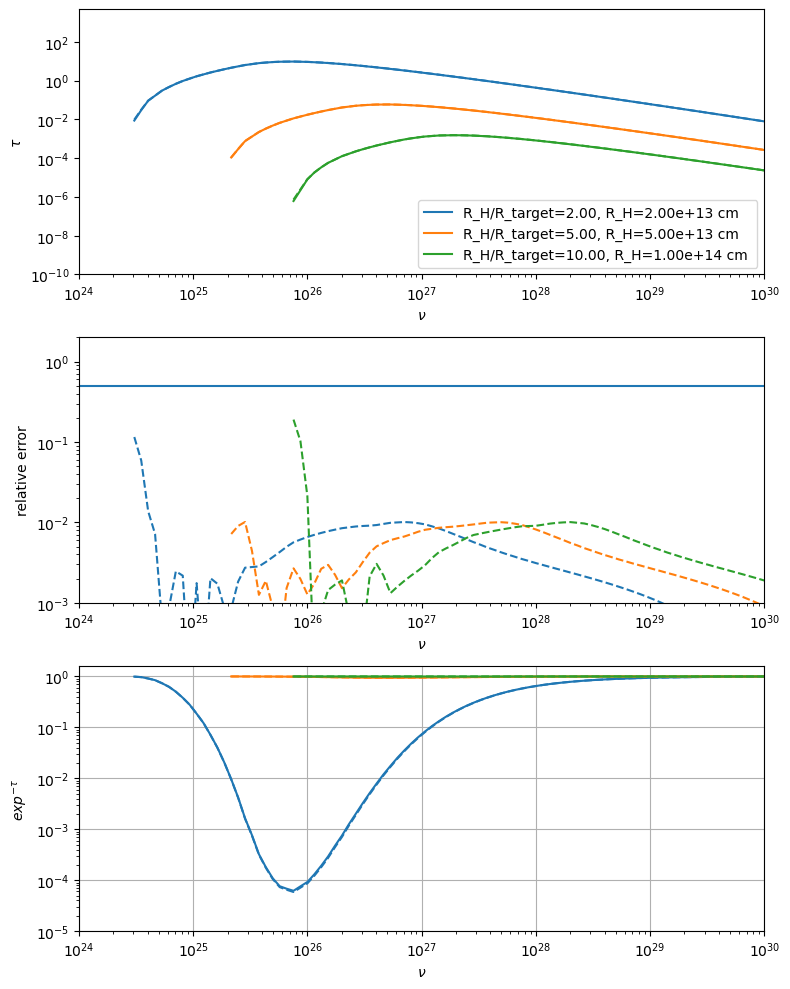

In [23]:
from matplotlib import pylab as plt
jetset_model.parameters.tau_BLR.val=0.1
#jetset_model.parameters.T_DT.val=1000
fig,axs=plt.subplots(3,1,figsize=(8,10))
R_H_corona=jetset_model.parameters.R_H_Corona.val
colors = ['C0','C1','C2']
comp='Corona'
jetset_model.enable_internal_absorption(comp,N_R_H=50,N_theta=50,N_soft=50,N_hard=50,use_R_H_profile_extrapolation=False)
nu_hard_min=1E24
nu_tau=np.logspace(np.log10(nu_hard_min),30,100)
for ID,f in enumerate([2.,5,10]):
    jetset_model.parameters.R_H.val=R_H_corona*f
    jetset_model.eval()
    jetset_model.enable_internal_absorption(comp,N_R_H=50,N_theta=50,N_soft=50,N_hard=50,use_R_H_profile_extrapolation=False)
    y,x=jetset_model.eval_internal_absorption(comp=comp,peak=False,nu=nu_tau)
    msk=y>1E-10

    x=x*u.Hz
    msk=y>1E-10

    axs[0].loglog( x[msk],y[msk],c=colors[ID],label='R_H/R_target=%2.2f, R_H=%2.2e cm '%(f,jetset_model.parameters.R_H.val))

    jetset_model.enable_internal_absorption(comp,N_R_H=50,N_theta=20,N_soft=20,N_hard=50,use_R_H_profile_extrapolation=False,use_sigma_gamma_gamma_fast=False)
    y1,x=jetset_model.eval_internal_absorption(comp=comp,peak=False,nu=nu_tau)
    x=x*u.Hz
    axs[0].loglog( x[msk] ,y1[msk] ,'--',c=colors[ID])

    axs[1].loglog( x[msk],np.fabs(y1[msk] -y [msk])/y[msk],'--',c=colors[ID])

    axs[2].loglog( x[msk],np.exp(-y[msk]),'-',c=colors[ID])
    axs[2].loglog( x[msk],np.exp(-y1[msk]),'--',c=colors[ID])
    try:
        x_min=min(nu_hard_min,x[msk].value.min()/2)
    except:
        x_min=None
axs[0].set_xlim(x_min,1E30)
axs[1].set_xlim(x_min,1E30)
axs[2].set_xlim(x_min,1E30)
axs[0].legend()


axs[1].axhline(.5)

axs[0].set_ylim(1E-10,5E3)
axs[1].set_ylim(1E-3,2)
axs[2].set_ylim(1E-5,)
axs[0].set_xlabel(r'$\nu$')
axs[1].set_xlabel(r'$\nu$')
axs[2].set_xlabel(r'$\nu$')

axs[0].set_ylabel(r'$\tau$')
axs[1].set_ylabel(r'relative error')
axs[2].set_ylabel(r'$exp^{-\tau}$')
plt.tight_layout()
plt.grid()

In [24]:
jetset_model.enable_internal_absorption(comp,N_R_H=50,N_theta=20,N_soft=20,N_hard=20,use_R_H_profile_extrapolation=False,use_sigma_gamma_gamma_fast=True)
%timeit y1,x=jetset_model.eval_internal_absorption(comp=comp,peak=False)

6.13 ms ± 50.3 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [25]:
jetset_model.enable_internal_absorption(comp,use_R_H_profile_extrapolation=True)
%timeit y1,x=jetset_model.eval_internal_absorption(comp=comp,peak=False)

889 μs ± 1.11 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [26]:
j=Jet()

In [27]:
nu=np.logspace(7,30,500)
y=j.eval(nu=nu,get_model=True)
nu_sync, y_sync = j.spectral_components.Sync.get_SED_points(lin_nu=nu, log_log=False, interp=j._jetkernel_interp)
nu_ssc,  y_ssc  = j.spectral_components.SSC.get_SED_points(lin_nu=nu, log_log=False, interp=j._jetkernel_interp)
y1=j.eval(nu=nu,get_model=True)
nu_sync, y_sync_1 = j.spectral_components.Sync.get_SED_points(lin_nu=nu, log_log=False, interp=j._jetkernel_interp)
nu_ssc,  y_ssc_1  = j.spectral_components.SSC.get_SED_points(lin_nu=nu, log_log=False, interp=j._jetkernel_interp)

In [28]:
import numpy as np
from jetset.jet_model import Jet


def build_jet():
    j = Jet(name="compact_int_abs", emitters_distribution="bkn", beaming_expr="bulk_theta")
    j.add_EC_component(EC_components_list=["EC_DT", "EC_BLR","EC_Corona"], disk_type="BB")

    j.parameters.z_cosm.val = 0.03
    j.parameters.L_Disk.val = 2e45
    j.parameters.R_H.val = 1e18
    j.parameters.tau_DT.val = 0.1
    j.parameters.tau_BLR.val = 0.1
    j.parameters.L_Corona.val = 5e44
    j.parameters.R_Corona.val = 5e15
    j.parameters.R_H_Corona.val = 2e17
    j.parameters.alpha_Corona.val = 1.1
    j.parameters.nu_cut_Corona.val = 1e20
    j.parameters.B.val = 0.2

    j.set_gamma_grid_size(120)
    j.set_IC_nu_size(80)
    return j


def stats(label, num, den):
    ratio = np.divide(num, den, out=np.full_like(num, np.nan), where=(den != 0))
    m = np.isfinite(ratio)
    print(f"{label}:")
    print(f"  max_ratio = {np.nanmax(ratio[m]):.6g}")
    print(f"  min_ratio = {np.nanmin(ratio[m]):.6g}")
    print(f"  n_ratio_gt_1.0001 = {np.sum(ratio[m] > 1.0001)}")
    print(f"  n_ratio_lt_0.9999 = {np.sum(ratio[m] < 0.9999)}")
    return ratio


j = build_jet()
nu = np.logspace(20, 29, 120)

# Cold vs warm, NO IA
y_cold = np.asarray(j.eval(nu=nu, get_model=True), dtype=float)
y_warm = np.asarray(j.eval(nu=nu, get_model=True), dtype=float)
stats("NO IA (warm / cold)", y_warm, y_cold)

# Enable IA
j.enable_internal_absorption("DT", N_soft=12, N_hard=12, N_R_H=10, N_theta=10, use_sigma_gamma_gamma_fast=True)
j.enable_internal_absorption("BLR", N_soft=12, N_hard=12, N_R_H=10, N_theta=10)
j.enable_internal_absorption("Corona", N_soft=12, N_hard=12, N_R_H=10, N_theta=10)

y_ia = np.asarray(j.eval(nu=nu, get_model=True), dtype=float)

stats("IA / cold", y_ia, y_cold)
r_ia_warm = stats("IA / warm", y_ia, y_warm)

idx = np.where(np.isfinite(r_ia_warm) & (r_ia_warm > 1.0001))[0]
print(f"IA/warm bins > 1.0001: {idx.size}")
if idx.size:
    print("first bins > 1.0001:", idx[:10])


NO IA (warm / cold):
  max_ratio = 1
  min_ratio = 1
  n_ratio_gt_1.0001 = 0
  n_ratio_lt_0.9999 = 0
IA / cold:
  max_ratio = 1
  min_ratio = 1.07958e-21
  n_ratio_gt_1.0001 = 0
  n_ratio_lt_0.9999 = 38
IA / warm:
  max_ratio = 1
  min_ratio = 1.07958e-21
  n_ratio_gt_1.0001 = 0
  n_ratio_lt_0.9999 = 38
IA/warm bins > 1.0001: 0


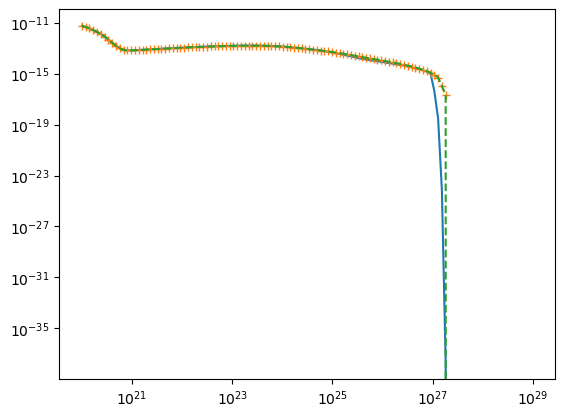

In [29]:
from matplotlib import pylab as plt
plt.loglog(nu,y_ia)
plt.loglog(nu,y_cold,'+')
plt.loglog(nu,y_warm,'--')

/var/folders/rs/w64c54l549x1jl7cp3m6x_q00000gn/T/ipykernel_97504/691292194.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(np.trapz(j.spectral_components.Corona.SED.nuLnu_src/j.spectral_components.Corona.SED.nu_src,j.spectral_components.Corona.SED.nu_src,))


4.92655058833799e+44 erg / s


/var/folders/rs/w64c54l549x1jl7cp3m6x_q00000gn/T/ipykernel_97504/691292194.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(np.trapz(j.spectral_components.Corona.SED.nuLnu_src/j.spectral_components.Corona.SED.nu_src,j.spectral_components.Corona.SED.nu_src,))


4.92655058833799e+44 erg / s


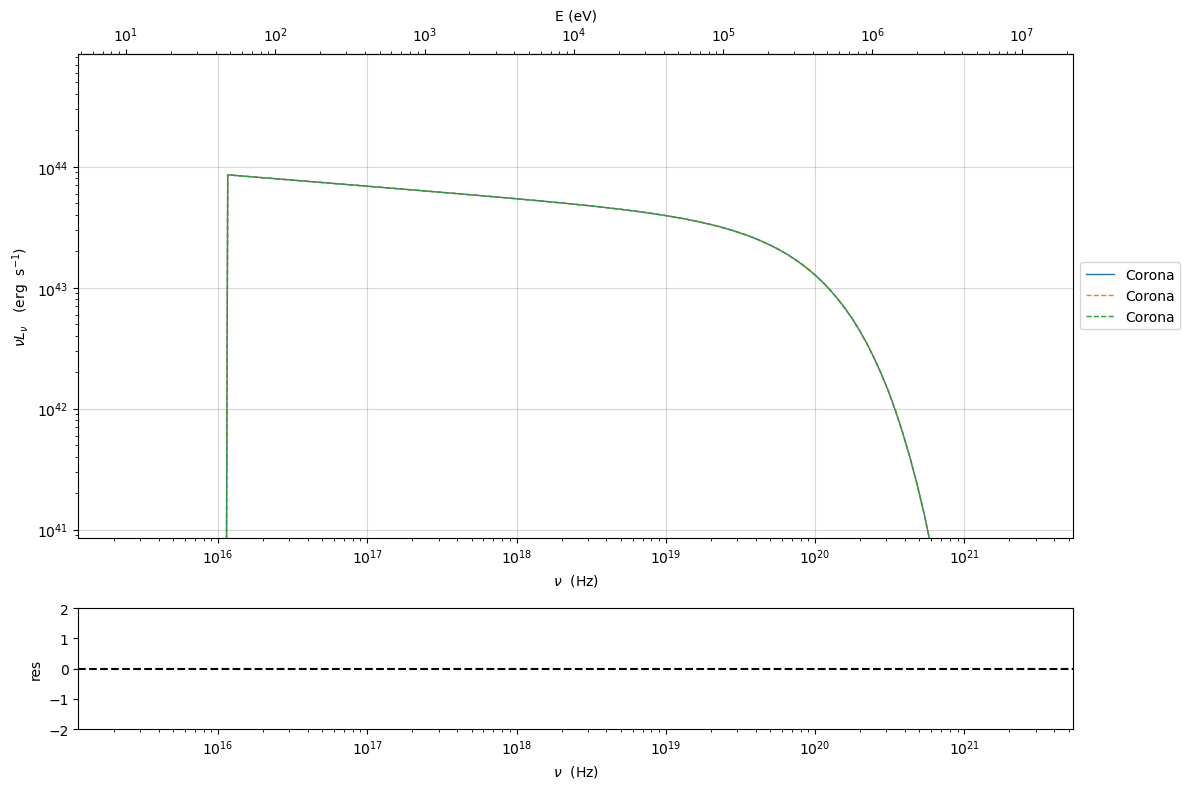

In [30]:
j = build_jet()
nu = np.logspace(20, 29, 120)

# Cold vs warm, NO IA
#print(j._blob.core.dist,j.cosmo._c)
j.eval()
#print(j._blob.core.dist,j.cosmo._c)

print(np.trapz(j.spectral_components.Corona.SED.nuLnu_src/j.spectral_components.Corona.SED.nu_src,j.spectral_components.Corona.SED.nu_src,))
p=j.plot_model(comp='Corona',frame='src')
j.eval()
print(np.trapz(j.spectral_components.Corona.SED.nuLnu_src/j.spectral_components.Corona.SED.nu_src,j.spectral_components.Corona.SED.nu_src,))

p=j.plot_model(plot_obj=p,comp='Corona',line_style='--',frame='src')
j.eval()
p=j.plot_model(plot_obj=p,comp='Corona',line_style='--',frame='src')

In [31]:
j = build_jet()
#print(j._blob.core.dist,j.cosmo._c)
j.get_DL_cm(eval_model=True)
print(j._blob.core.dist,j.cosmo._c)
j.eval()
print(j._blob.core.dist,j.cosmo._c)
j.get_DL_cm()
print(j._blob.core.dist,j.cosmo._c)

4.188398477600799e+26 FlatLambdaCDM(name="Planck13", H0=67.77 km / (Mpc s), Om0=0.30712, Tcmb0=2.7255 K, Neff=3.046, m_nu=[0.   0.   0.06] eV, Ob0=0.048252)
4.188398477600799e+26 FlatLambdaCDM(name="Planck13", H0=67.77 km / (Mpc s), Om0=0.30712, Tcmb0=2.7255 K, Neff=3.046, m_nu=[0.   0.   0.06] eV, Ob0=0.048252)
4.188398477600799e+26 FlatLambdaCDM(name="Planck13", H0=67.77 km / (Mpc s), Om0=0.30712, Tcmb0=2.7255 K, Neff=3.046, m_nu=[0.   0.   0.06] eV, Ob0=0.048252)
